# Nishanth MS

## 1. Data Loading and Basic Checking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("netflix_titles.csv")

In [3]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## 2. Data Cleaning

In [8]:
df = df.drop(columns=['director'])

In [9]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
listed_in,0


In [10]:
df['cast'] = df['cast'].fillna('No Cast Info')

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,0
country,831
date_added,10
release_year,0
rating,4
duration,3
listed_in,0


In [12]:
most_common_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(most_common_country)

In [13]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3
listed_in,0


In [14]:
most_common_date = df['date_added'].mode()[0]
df['date_added'] = df['date_added'].fillna(most_common_date)

In [15]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3
listed_in,0


In [16]:
most_common_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(most_common_rating)

In [17]:
df = df.dropna(subset=['duration'])

In [18]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [19]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [20]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [21]:
df['type'] = df['type'].str.upper()
df['rating'] = df['rating'].str.upper()

In [53]:
df['type'].unique()

array(['MOVIE', 'TV SHOW'], dtype=object)

In [54]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

## 3. Univariate and Bivariate Analysis

In [23]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8804 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8804 non-null   object        
 1   type          8804 non-null   object        
 2   title         8804 non-null   object        
 3   cast          8804 non-null   object        
 4   country       8804 non-null   object        
 5   date_added    8804 non-null   datetime64[ns]
 6   release_year  8804 non-null   int64         
 7   rating        8804 non-null   object        
 8   duration      8804 non-null   object        
 9   listed_in     8804 non-null   object        
 10  description   8804 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 825.4+ KB


In [29]:
most_common = df['rating'].value_counts()

In [30]:
most_common.index[0]

'TV-MA'

In [31]:
top5_countries = df['country'].value_counts().head(5)

In [32]:
top5_countries

,count
country,
United States,3646
India,972
United Kingdom,419
Japan,245
South Korea,199


In [33]:
avg_release_year = df.groupby('type')['release_year'].mean()

In [34]:
avg_release_year

,release_year
type,
MOVIE,2013.121084
TV SHOW,2016.605755


## 4. Trend and Relationship Exploration

In [35]:
content_count = df['type'].value_counts()

In [36]:
content_count

,count
type,
MOVIE,6128
TV SHOW,2676


In [38]:
titles_per_year = df.groupby('release_year')['title'].count()

In [39]:
titles_per_year

,title
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1031
2018,1147
2019,1030


In [40]:
df['year_added'] = df['date_added'].dt.year

In [41]:
titles_per_year = df.groupby('year_added')['title'].count()

In [42]:
titles_per_year

,title
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,427


In [43]:
peak_year  = titles_per_year.idxmax()
peak_count = titles_per_year.max()
low_year  = titles_per_year.idxmin()
low_count = titles_per_year.min()
first_year = titles_per_year.index[0]
last_year  = titles_per_year.index[-1]


In [44]:
print(f"Peak Year : {peak_year} ({peak_count} titles)")
print(f"Lowest Year : {low_year} ({low_count} titles)")
print(f"First Year : {first_year}")
print(f"Last Year : {last_year}")
print(f"Total Years : {last_year - first_year}")

Peak Year : 2019 (2016 titles)
Lowest Year : 2010 (1 titles)
First Year : 2008
Last Year : 2021
Total Years : 13


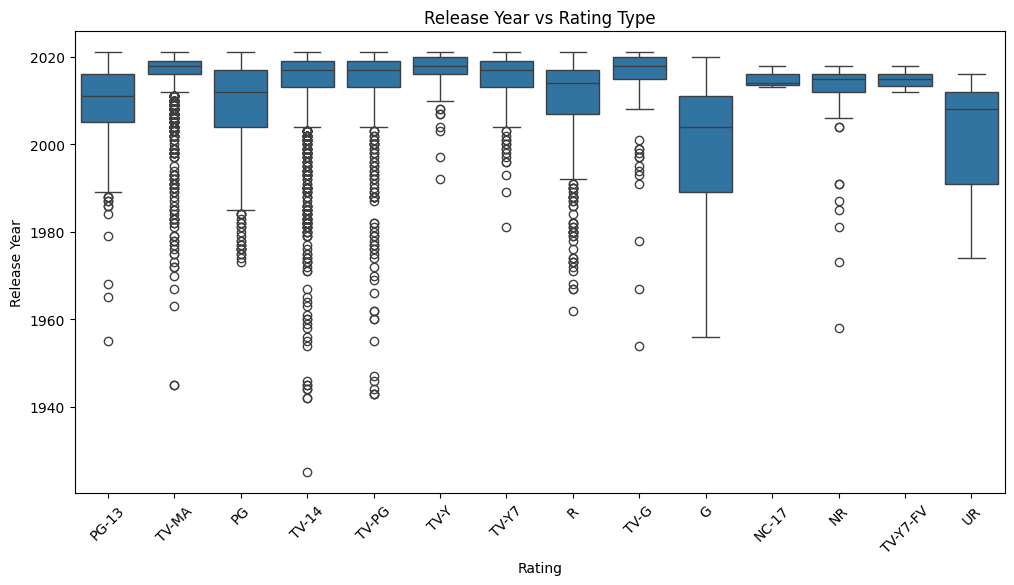

In [45]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='rating', y='release_year', data=df)
plt.title('Release Year vs Rating Type')
plt.xlabel('Rating')
plt.ylabel('Release Year')
plt.xticks(rotation=45)
plt.show()

## 5. Visualizations

/tmp/ipython-input-767/1513812224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set1')


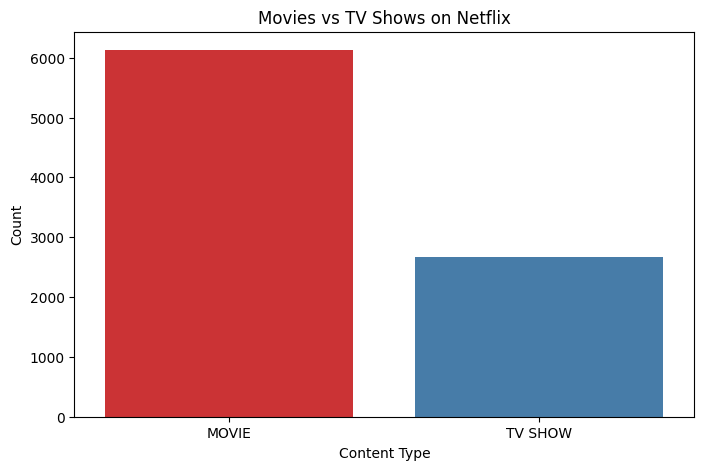

In [46]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', data=df, palette='Set1')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

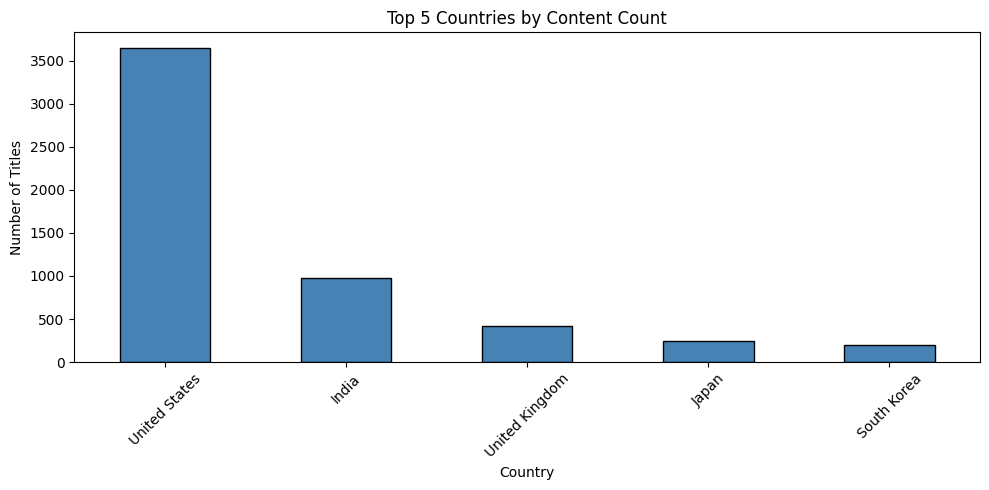

In [48]:
top5 = df['country'].value_counts().head(5)

plt.figure(figsize=(10, 5))
top5.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 5 Countries by Content Count')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

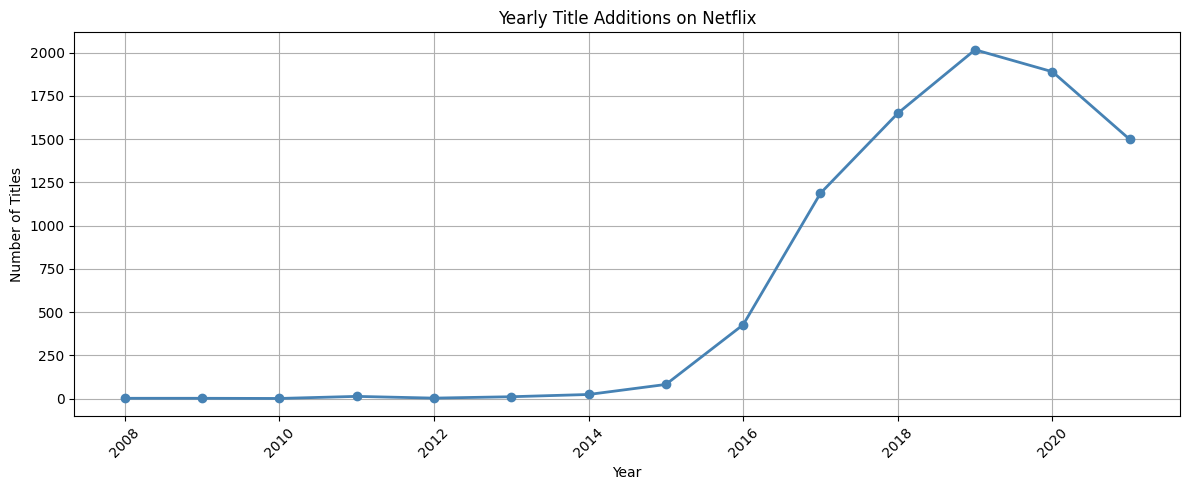

In [49]:
titles_per_year = df.groupby('year_added')['title'].count()

plt.figure(figsize=(12, 5))
plt.plot(titles_per_year.index, titles_per_year.values,marker='o', color='steelblue', linewidth=2)
plt.title('Yearly Title Additions on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-767/635803997.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_numeric'] = df['duration'].str.extract('(\d+)').astype(int)


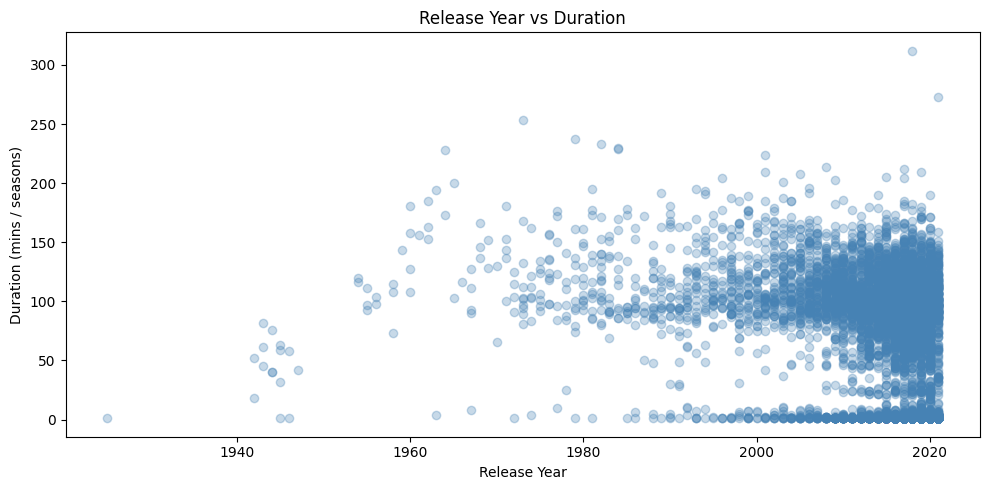

In [51]:
df['duration_numeric'] = df['duration'].str.extract('(\d+)').astype(int)

plt.figure(figsize=(10, 5))
plt.scatter(df['release_year'], df['duration_numeric'],alpha=0.3, color='steelblue')
plt.title('Release Year vs Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (mins / seasons)')
plt.tight_layout()
plt.show()

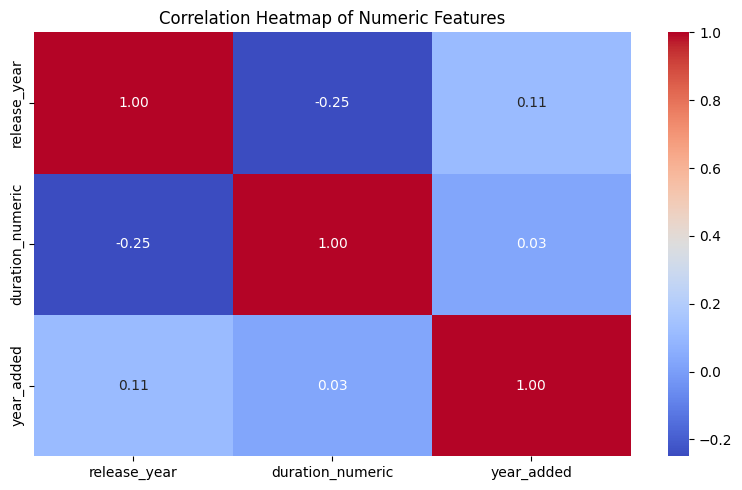

In [52]:
numeric_df = df[['release_year', 'duration_numeric', 'year_added']]

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## 6. Conclusion and Insights

1. Summarize key findings about Netflix content trends.

Netflix has 8807 titles where Movies dominate
with 70% of content compared to TV Shows with
30%. The most common rating is TV-MA which shows
most content targets mature audiences. United
States produces the most content followed by
India and United Kingdom. Netflix grew rapidly
from 2014 to 2019 with peak additions in 2019
and slightly declined after 2020.


2. Recommend one actionable insight for Netflix content strategy based on data patterns.

Based on the data patterns I observed, I recommend
that Netflix should invest more in producing TV Shows
especially in regional languages from countries like
India, Japan and South Korea. This is because TV Shows
keep the audience engaged for a longer period of time
through multiple episodes and seasons which increases
the overall watch time on the platform. Currently TV
Shows make up only 30% of the total content which
clearly shows there is a huge room for growth in this
area. Also focusing on TV-MA and TV-14 rated content
would be beneficial since these are the most popular
rating categories among Netflix viewers.